In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv('data.csv')
df

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,...,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,...,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,...,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,...,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,...,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,...,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,...,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,...,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,...,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850


In [3]:
pd.options.display.max_columns = None

In [4]:
df.head()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


In [5]:
df.tail()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,0,Male,145,36.1,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,0,Male,134,31.3,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,1,Male,151,NaN,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,0,Male,66,26.6,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850
24999,29999,8,2,0,Business,4,150 to 175,5882,22,1,0,Male,245,41.6,formerly smoked,2014.0,Chennai,57,N,No,No,4,21,6170


In [6]:
# Dimensions of the dataset
df.shape

(25000, 24)

In [7]:
# Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

In [8]:
# Cheking missing value
df.isnull().sum()

applicant_id                          0
years_of_insurance_with_us            0
regular_checkup_lasy_year             0
adventure_sports                      0
Occupation                            0
visited_doctor_last_1_year            0
cholesterol_level                     0
daily_avg_steps                       0
age                                   0
heart_decs_history                    0
other_major_decs_history              0
Gender                                0
avg_glucose_level                     0
bmi                                 990
smoking_status                        0
Year_last_admitted                11881
Location                              0
weight                                0
covered_by_any_other_company          0
Alcohol                               0
exercise                              0
weight_change_in_last_one_year        0
fat_percentage                        0
insurance_cost                        0
dtype: int64

In [9]:
# checking for duplicate values
df.duplicated().sum() 

0

In [10]:
# Descriptive summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


- We see that the applicant_id and Year_last_admitted columns are not going to relevant for the analysis
- 
So we will drop these variables

In [11]:
df.drop(['applicant_id', 'Year_last_admitted'], axis = 1, inplace = True)

In [12]:
# in the 'bmi' columns there are some missing values are present we impute that with mean
df.loc[:, 'bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   years_of_insurance_with_us      25000 non-null  int64  
 1   regular_checkup_lasy_year       25000 non-null  int64  
 2   adventure_sports                25000 non-null  int64  
 3   Occupation                      25000 non-null  object 
 4   visited_doctor_last_1_year      25000 non-null  int64  
 5   cholesterol_level               25000 non-null  object 
 6   daily_avg_steps                 25000 non-null  int64  
 7   age                             25000 non-null  int64  
 8   heart_decs_history              25000 non-null  int64  
 9   other_major_decs_history        25000 non-null  int64  
 10  Gender                          25000 non-null  object 
 11  avg_glucose_level               25000 non-null  int64  
 12  bmi                             

# Univariate Analysis

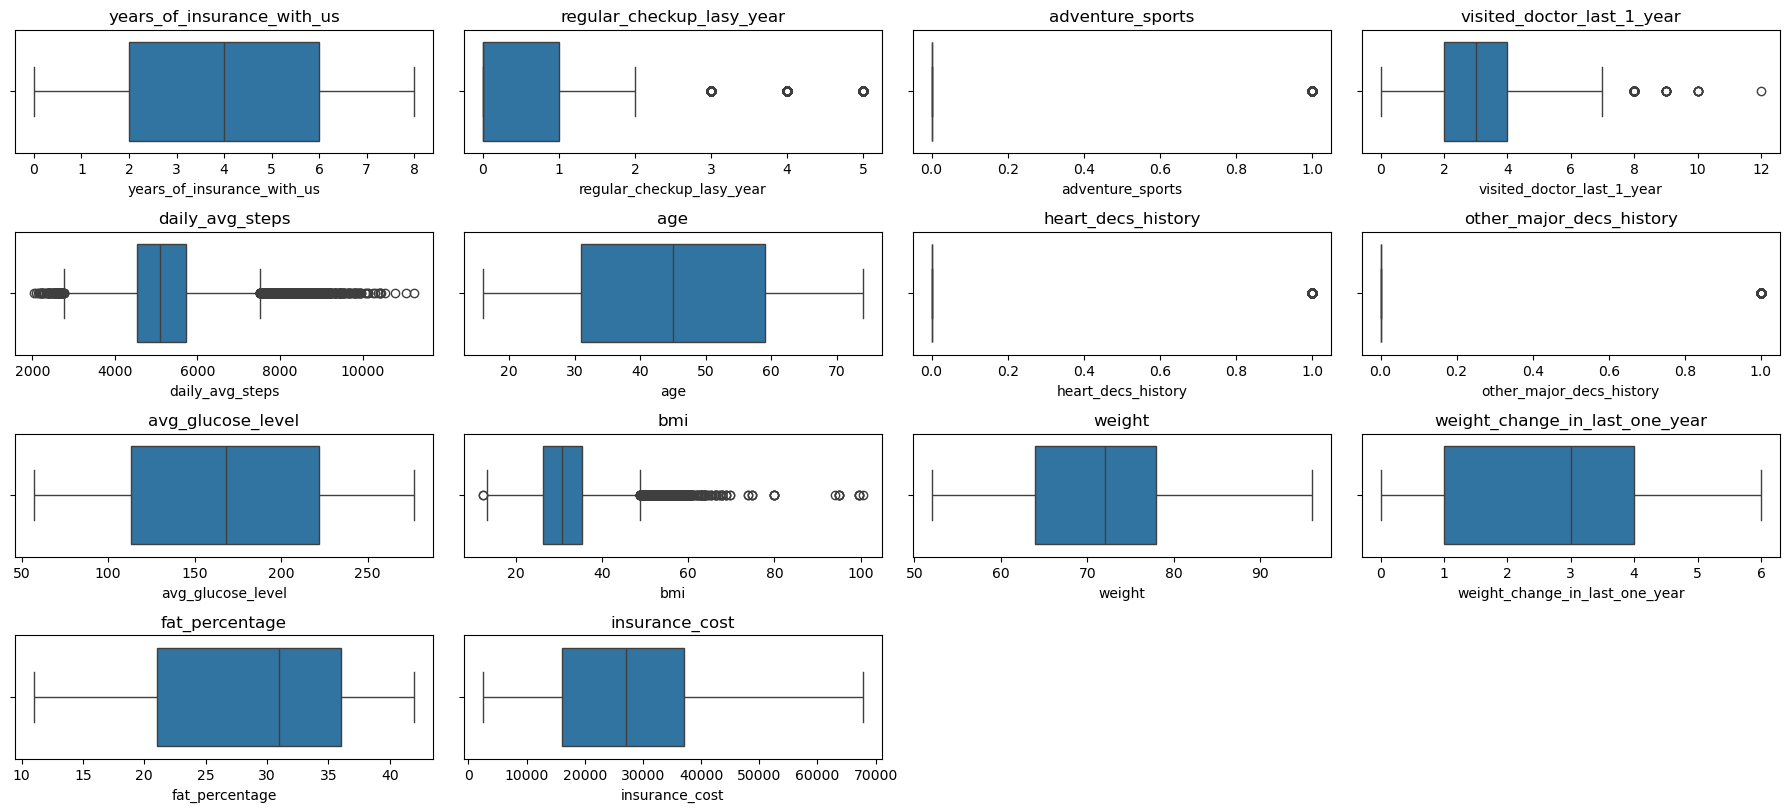

In [14]:
#Get boxplots for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.tight_layout()
    plt.title(variable)
plt.show()

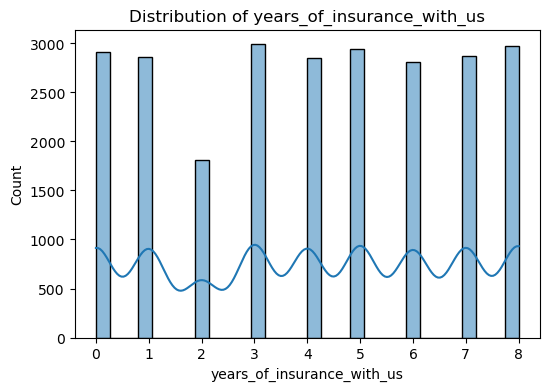

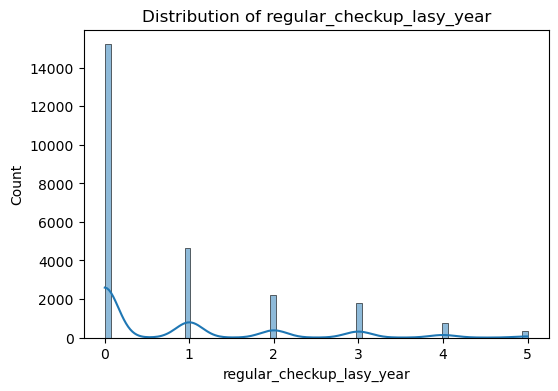

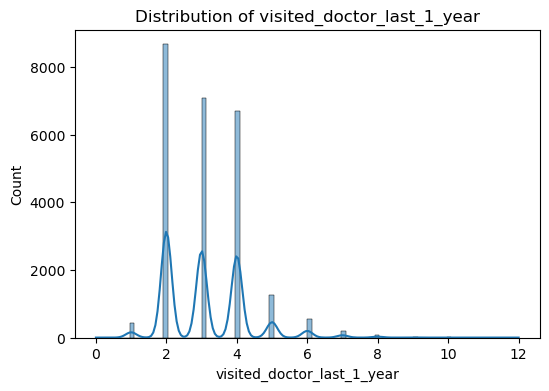

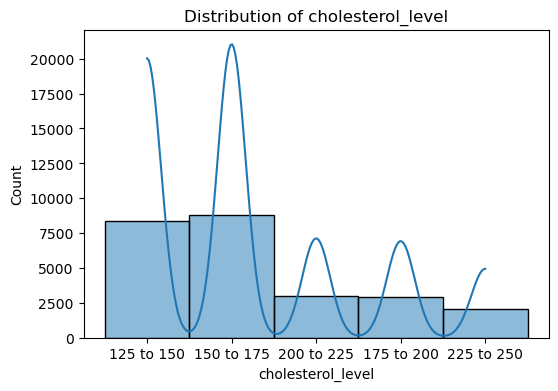

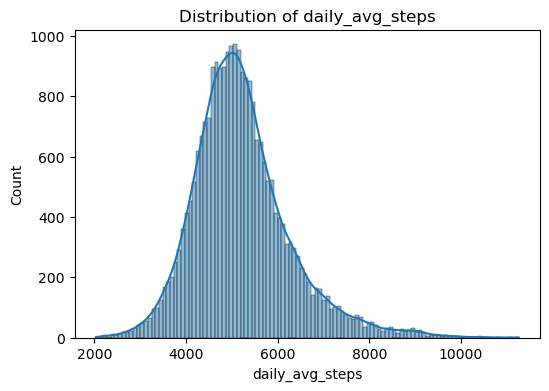

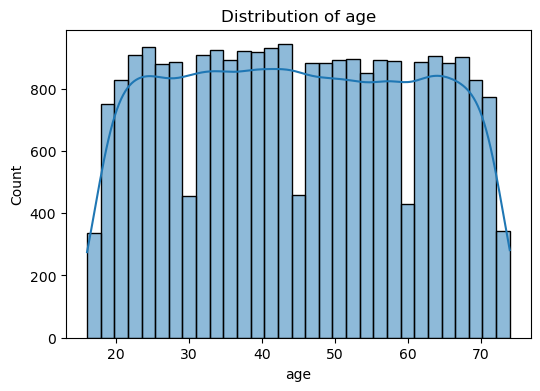

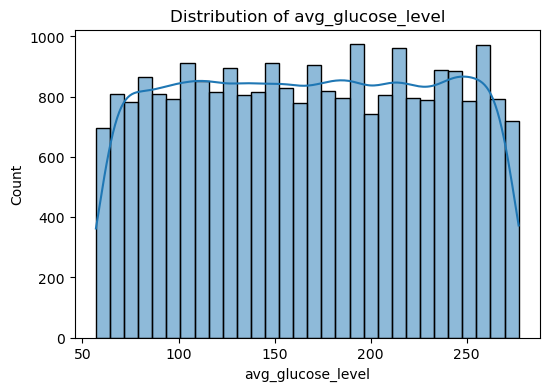

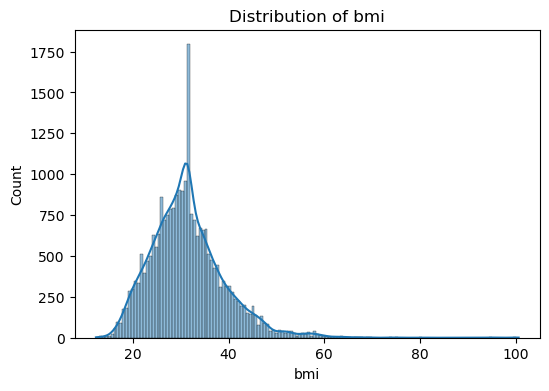

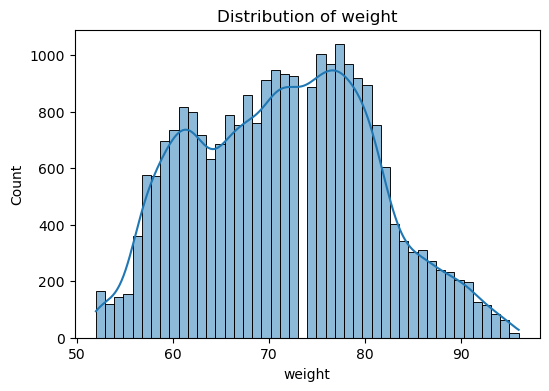

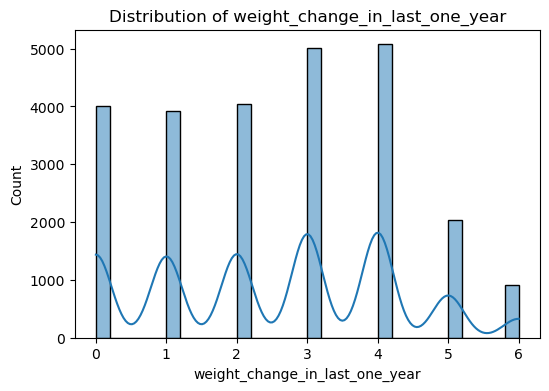

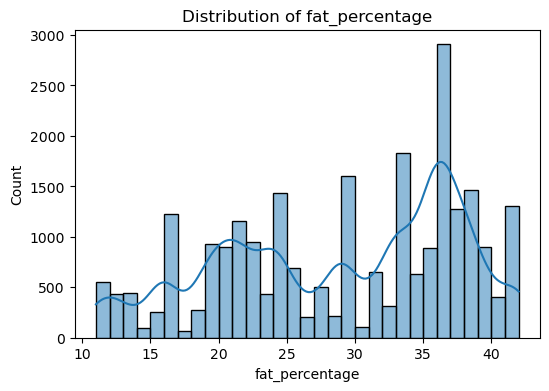

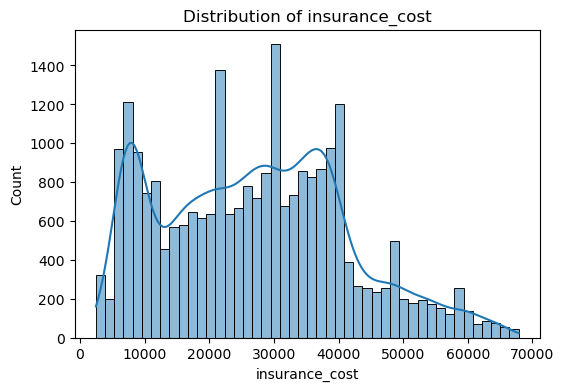

In [15]:
continuous_columns = ['years_of_insurance_with_us', 'regular_checkup_lasy_year', 
                      'visited_doctor_last_1_year', 'cholesterol_level', 
                      'daily_avg_steps', 'age', 'avg_glucose_level', 
                      'bmi', 'weight', 'weight_change_in_last_one_year', 
                      'fat_percentage', 'insurance_cost']

for col in continuous_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

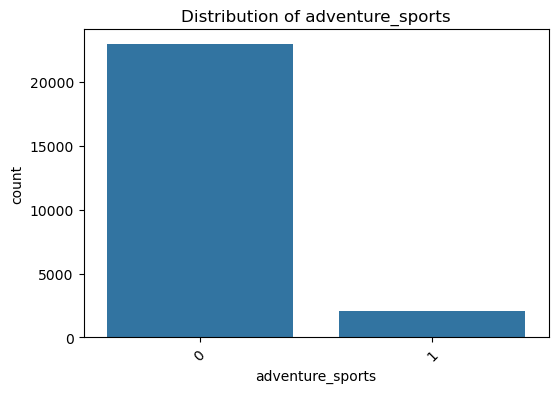

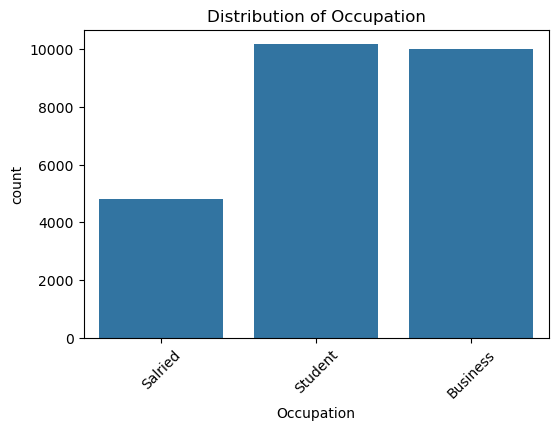

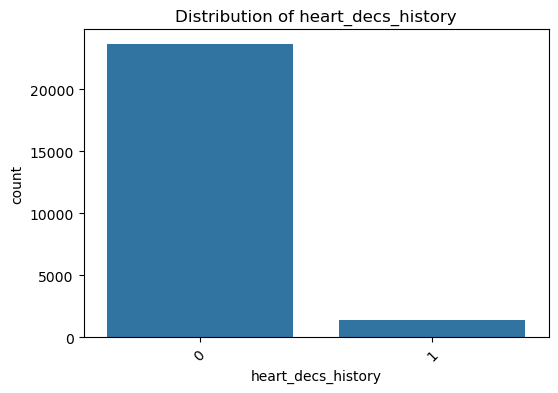

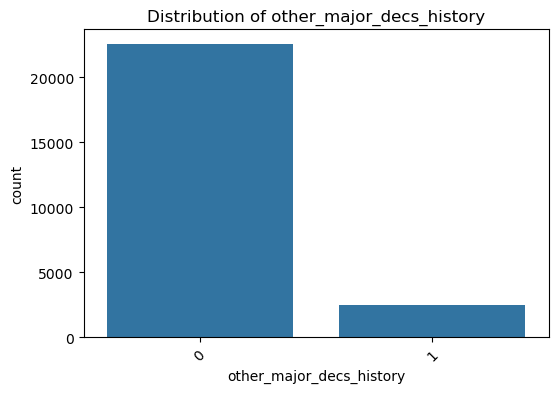

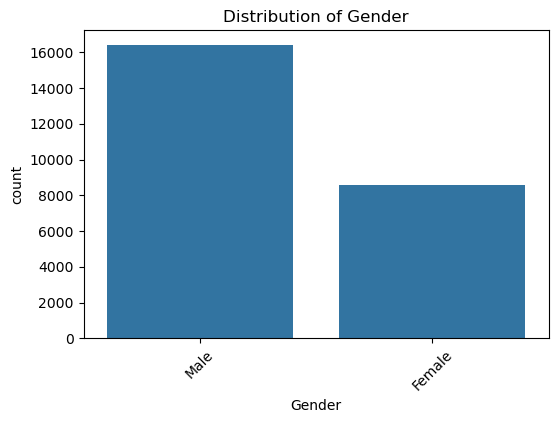

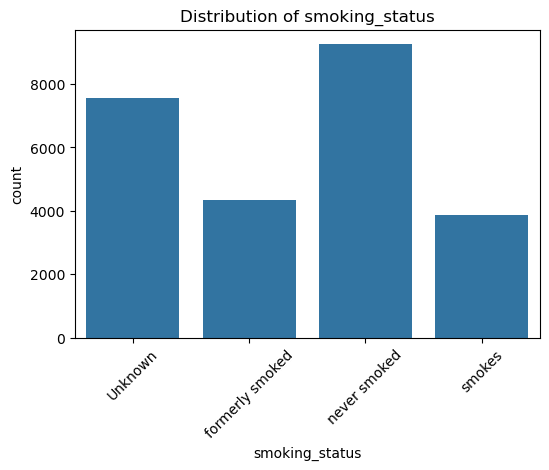

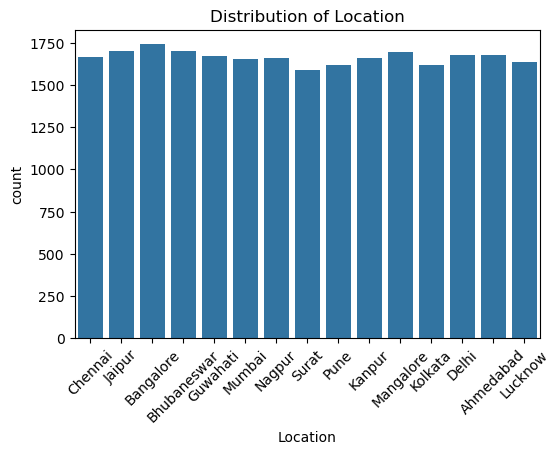

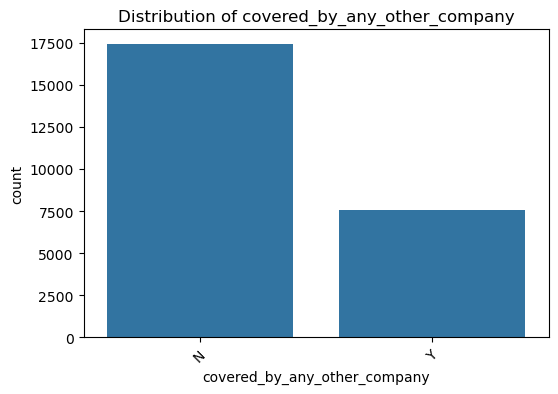

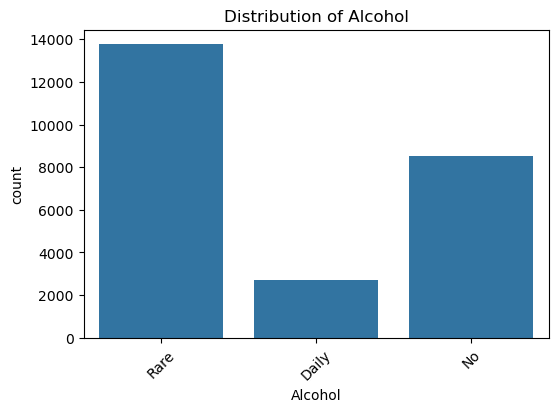

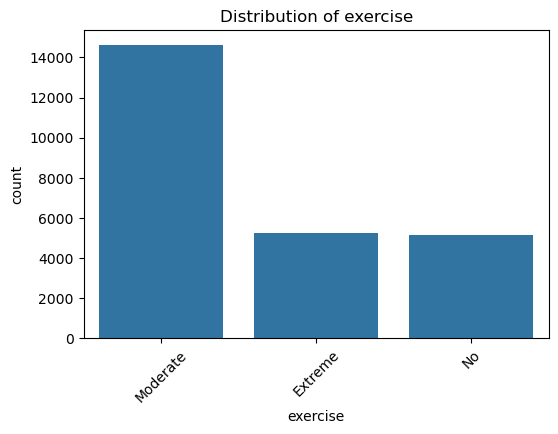

In [16]:
categorical_columns = ['adventure_sports', 'Occupation', 'heart_decs_history', 
                       'other_major_decs_history', 'Gender', 'smoking_status', 
                       'Location', 'covered_by_any_other_company', 'Alcohol', 
                       'exercise']
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Bivariate Analysis

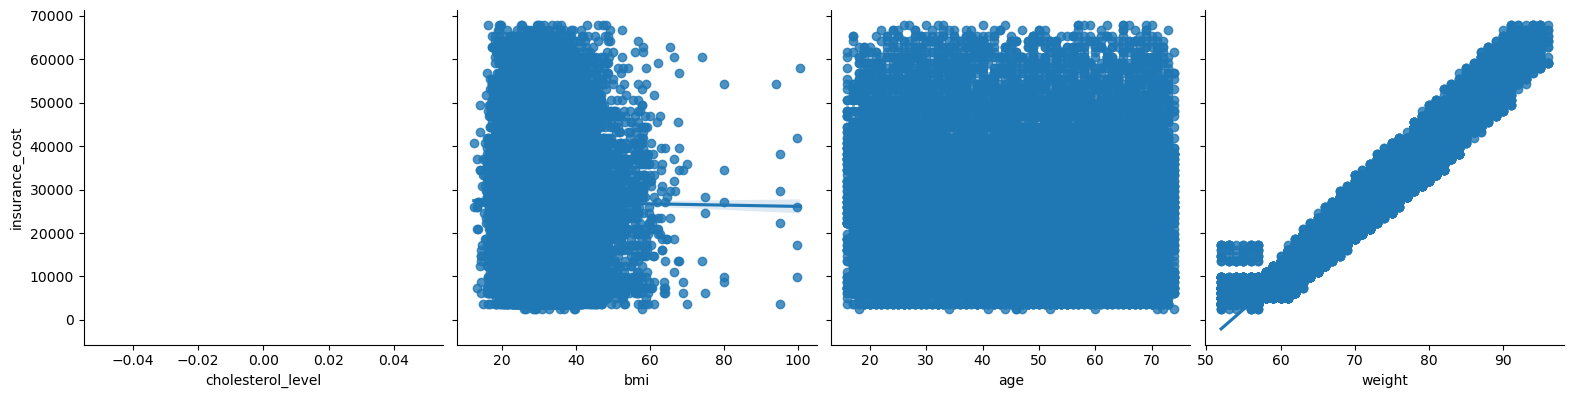

In [17]:
numeric_columns = ['cholesterol_level', 'bmi', 'age', 'weight', 'insurance_cost']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
sns.pairplot(df, x_vars=['cholesterol_level', 'bmi', 'age', 'weight'], 
             y_vars='insurance_cost', kind='reg', height=4)
plt.show()

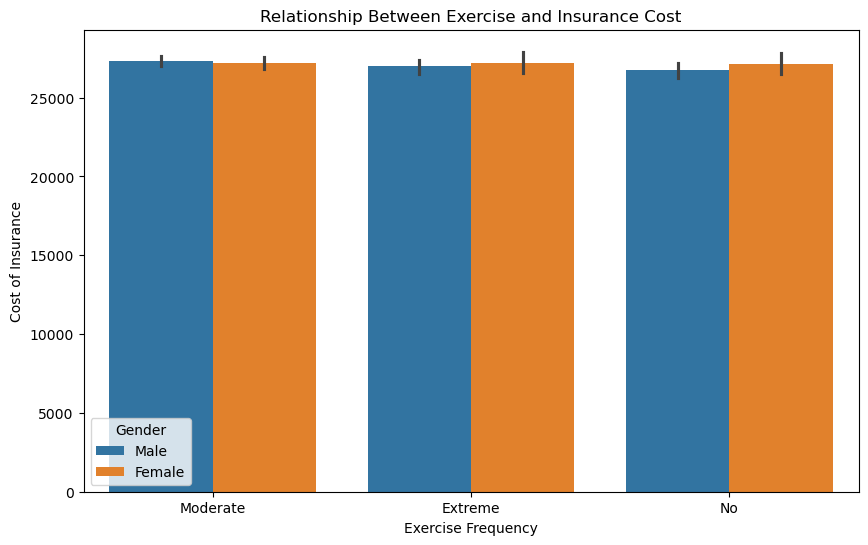

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='exercise', y='insurance_cost', hue='Gender', data=df)
plt.title('Relationship Between Exercise and Insurance Cost')
plt.xlabel('Exercise Frequency')
plt.ylabel('Cost of Insurance')
plt.show()


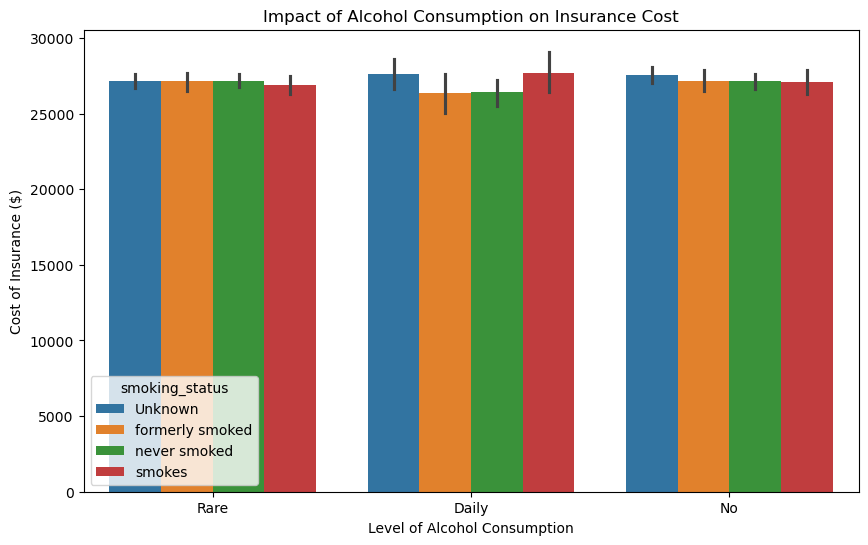

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Alcohol', y='insurance_cost', hue='smoking_status', data=df)
plt.title('Impact of Alcohol Consumption on Insurance Cost')
plt.xlabel('Level of Alcohol Consumption')
plt.ylabel('Cost of Insurance ($)')
plt.show()

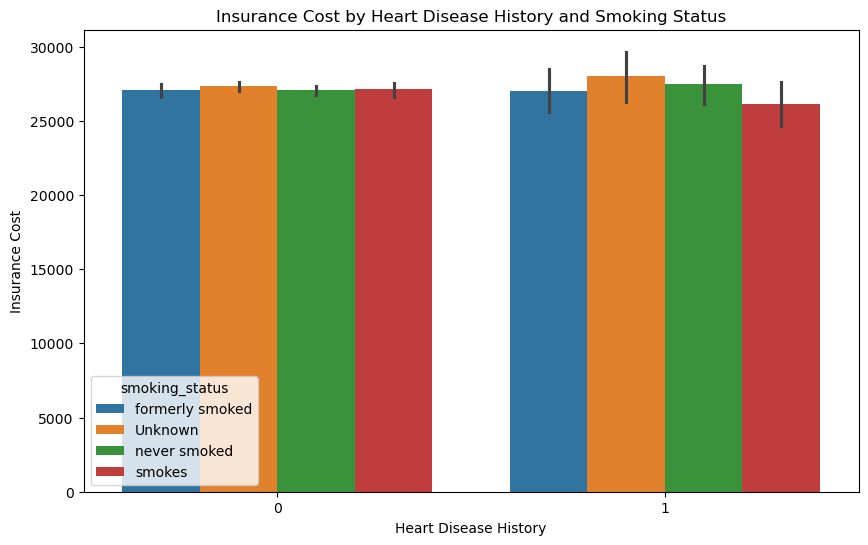

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='heart_decs_history', y='insurance_cost', hue='smoking_status', data=df)
plt.title('Insurance Cost by Heart Disease History and Smoking Status')
plt.xlabel('Heart Disease History')
plt.ylabel('Insurance Cost')
plt.show()

In [21]:
# Outlier treatment
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

columns_with_outliers = ['regular_checkup_lasy_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'heart_decs_history', 'other_major_decs_history', 'bmi']
for column in columns_with_outliers:
    cap_outliers_iqr(df, column)

In [22]:
# Check for data imbalance
print("Value Counts for Categorical Variables:")
for col in ['Gender', 'smoking_status', 'Location']:
    print(df[col].value_counts())

Value Counts for Categorical Variables:
Gender
Male      16422
Female     8578
Name: count, dtype: int64
smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64
Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664
Nagpur         1663
Mumbai         1658
Lucknow        1637
Pune           1622
Kolkata        1620
Surat          1589
Name: count, dtype: int64


In [23]:
# Clustering on numerical variables only
numerical_features = df[['age', 'bmi', 'insurance_cost']]
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)

In [24]:
# Applying KMeans for 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(numerical_features_scaled)

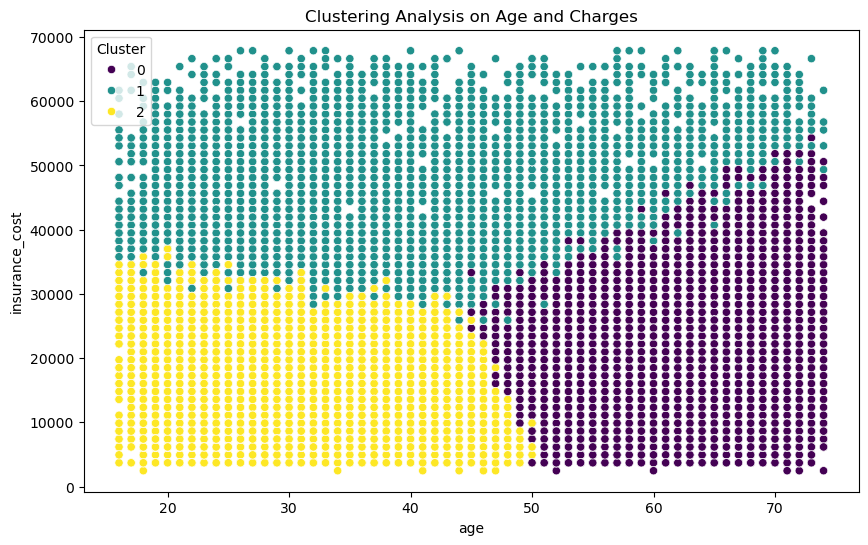

In [25]:
# Visualizing clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='insurance_cost', hue='Cluster', palette='viridis')
plt.title('Clustering Analysis on Age and Charges')
plt.show()

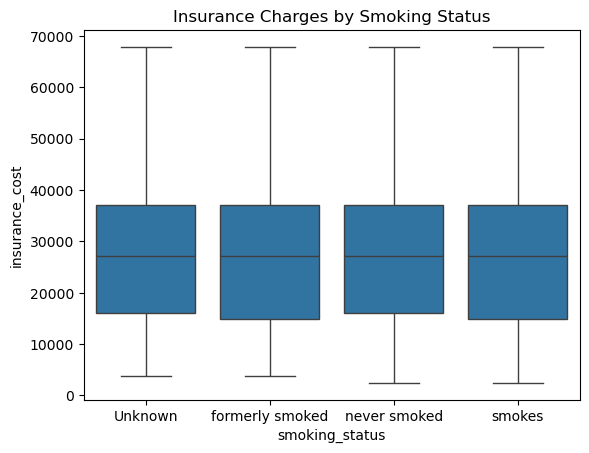

In [26]:
# Further insights may involve analyzing the differences in charges between smokers and non-smokers, as well as identifying regions associated with higher charges.
sns.boxplot(data=df, x='smoking_status', y='insurance_cost')
plt.title('Insurance Charges by Smoking Status')
plt.show()

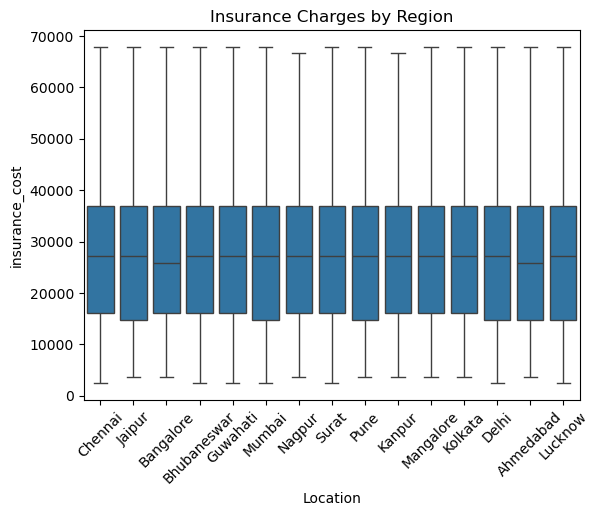

In [27]:
sns.boxplot(data=df, x='Location', y='insurance_cost')
plt.title('Insurance Charges by Region')
plt.xticks(rotation=45)
plt.show()

# Model building and interpretation.

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [29]:
# Example columns to encode
ordinal_columns = ['smoking_status', 'cholesterol_level']  # Replace with your ordinal columns
nominal_columns = ['Occupation', 'Gender', 'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise']

In [30]:
# Label Encoding for ordinal columns
label_encoders = {}
for col in ordinal_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [31]:
# One-Hot Encoding for nominal columns with meaningful names
for col in nominal_columns:
    one_hot = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df.drop(columns=[col]), one_hot], axis=1)

In [32]:
df

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,smoking_status,weight,weight_change_in_last_one_year,fat_percentage,insurance_cost,Cluster,Occupation_Business,Occupation_Salried,Occupation_Student,Gender_Female,Gender_Male,Location_Ahmedabad,Location_Bangalore,Location_Bhubaneswar,Location_Chennai,Location_Delhi,Location_Guwahati,Location_Jaipur,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mangalore,Location_Mumbai,Location_Nagpur,Location_Pune,Location_Surat,covered_by_any_other_company_N,covered_by_any_other_company_Y,Alcohol_Daily,Alcohol_No,Alcohol_Rare,exercise_Extreme,exercise_Moderate,exercise_No
0,3,1.0,0.0,2.0,0,4866.0,28,0.0,0.0,97,31.200000,0,67,1,25,20978,2,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
1,0,0.0,0.0,4.0,0,6411.0,50,0.0,0.0,212,34.200000,1,58,3,27,6170,2,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,1,0.0,0.0,4.0,0,4509.0,68,0.0,0.0,166,40.400000,1,73,0,32,28382,0,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False
3,7,2.5,0.0,2.0,0,6214.0,51,0.0,0.0,109,22.900000,0,71,3,37,27148,0,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
4,3,1.0,0.0,2.0,0,4938.0,44,0.0,0.0,118,26.500000,2,74,0,34,29616,1,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,3,0.0,0.0,4.0,0,5614.0,22,0.0,0.0,145,36.100000,3,79,4,40,39488,1,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False
24996,6,0.0,0.0,4.0,0,4719.0,58,0.0,0.0,134,31.300000,2,66,2,28,14808,0,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
24997,7,0.0,0.0,2.0,0,5624.0,34,0.0,0.0,151,31.393328,0,76,1,35,33318,1,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
24998,1,0.0,0.0,2.0,0,7510.5,27,0.0,0.0,66,26.600000,0,74,0,40,30850,2,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,True,False


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [34]:
X = df.drop(["insurance_cost"], axis=1)

y = df.pop("insurance_cost")

In [35]:
X.head()

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,smoking_status,weight,weight_change_in_last_one_year,fat_percentage,Cluster,Occupation_Business,Occupation_Salried,Occupation_Student,Gender_Female,Gender_Male,Location_Ahmedabad,Location_Bangalore,Location_Bhubaneswar,Location_Chennai,Location_Delhi,Location_Guwahati,Location_Jaipur,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mangalore,Location_Mumbai,Location_Nagpur,Location_Pune,Location_Surat,covered_by_any_other_company_N,covered_by_any_other_company_Y,Alcohol_Daily,Alcohol_No,Alcohol_Rare,exercise_Extreme,exercise_Moderate,exercise_No
0,3,1.0,0.0,2.0,0,4866.0,28,0.0,0.0,97,31.2,0,67,1,25,2,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
1,0,0.0,0.0,4.0,0,6411.0,50,0.0,0.0,212,34.2,1,58,3,27,2,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,1,0.0,0.0,4.0,0,4509.0,68,0.0,0.0,166,40.4,1,73,0,32,0,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False
3,7,2.5,0.0,2.0,0,6214.0,51,0.0,0.0,109,22.9,0,71,3,37,0,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
4,3,1.0,0.0,2.0,0,4938.0,44,0.0,0.0,118,26.5,2,74,0,34,1,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False


In [36]:
y.head()

0    20978
1     6170
2    28382
3    27148
4    29616
Name: insurance_cost, dtype: int64

In [37]:
# Split the dataset into Train and Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

In [38]:
#Scaling of features is done to bring all the features to the same scale.
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)

In [39]:
X_train_scaled.head()

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,smoking_status,weight,weight_change_in_last_one_year,fat_percentage,Cluster,Occupation_Business,Occupation_Salried,Occupation_Student,Gender_Female,Gender_Male,Location_Ahmedabad,Location_Bangalore,Location_Bhubaneswar,Location_Chennai,Location_Delhi,Location_Guwahati,Location_Jaipur,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mangalore,Location_Mumbai,Location_Nagpur,Location_Pune,Location_Surat,covered_by_any_other_company_N,covered_by_any_other_company_Y,Alcohol_Daily,Alcohol_No,Alcohol_Rare,exercise_Extreme,exercise_Moderate,exercise_No
0,-1.572831,1.471346,0.0,0.815534,0.0,0.066506,0.003132,0.0,0.0,-0.592260,0.591225,1.515950,0.254457,-0.898260,-0.563041,0.042572,-0.817566,-0.487287,1.205850,-0.721857,0.721857,-0.269138,-0.273266,-0.274592,-0.267547,-0.266442,-0.270357,-0.269504,-0.265703,-0.259612,-0.266319,-0.265827,-0.262857,-0.26987,3.772351,-0.262485,0.663930,-0.663930,-0.348888,-0.723048,0.907880,-0.512915,0.838845,-0.5074
1,0.728712,1.471346,0.0,-0.081953,0.0,2.409803,0.934323,0.0,0.0,1.336469,-0.012950,-1.285140,-0.493965,0.282329,1.291771,-1.157123,-0.817566,2.052178,-0.829291,-0.721857,0.721857,-0.269138,-0.273266,3.641762,-0.267547,-0.266442,-0.270357,-0.269504,-0.265703,-0.259612,-0.266319,-0.265827,-0.262857,-0.26987,-0.265087,-0.262485,-1.506182,1.506182,-0.348888,-0.723048,0.907880,-0.512915,0.838845,-0.5074
2,0.728712,-0.710966,0.0,0.815534,0.0,0.669526,-0.245185,0.0,0.0,-1.596474,0.028264,1.515950,1.216715,0.872624,-0.910819,0.042572,1.223143,-0.487287,-0.829291,-0.721857,0.721857,-0.269138,-0.273266,-0.274592,-0.267547,-0.266442,-0.270357,-0.269504,-0.265703,3.851896,-0.266319,-0.265827,-0.262857,-0.26987,-0.265087,-0.262485,0.663930,-0.663930,-0.348888,-0.723048,0.907880,-0.512915,0.838845,-0.5074
3,0.728712,0.380190,0.0,-0.081953,0.0,-0.742347,0.623926,0.0,0.0,1.527748,0.211859,-0.351443,1.323632,0.872624,-1.954150,0.042572,-0.817566,2.052178,-0.829291,-0.721857,0.721857,-0.269138,-0.273266,-0.274592,-0.267547,-0.266442,-0.270357,-0.269504,-0.265703,-0.259612,3.754893,-0.265827,-0.262857,-0.26987,-0.265087,-0.262485,0.663930,-0.663930,-0.348888,1.383034,-1.101467,-0.512915,0.838845,-0.5074
4,-0.038469,2.016924,0.0,-0.081953,0.0,2.409803,-1.238456,0.0,0.0,-0.321281,0.942489,0.582253,0.789045,-1.488554,0.828068,0.042572,1.223143,-0.487287,-0.829291,-0.721857,0.721857,-0.269138,-0.273266,-0.274592,-0.267547,-0.266442,-0.270357,-0.269504,-0.265703,-0.259612,-0.266319,-0.265827,-0.262857,-0.26987,-0.265087,3.809749,0.663930,-0.663930,-0.348888,-0.723048,0.907880,-0.512915,0.838845,-0.5074


### Metric of Choice

In [40]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    y_pred = model.predict(predictors)

    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    acc = accuracy_score(target, y_pred)  # to compute Accuracy
    recall = recall_score(target, y_pred)  # to compute Recall
    precision = precision_score(target, y_pred)  # to compute Precision
    f1 = f1_score(target, y_pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [41]:
def model_confusion_matrix(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [42]:
# Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [43]:
# Predictions and Evaluation of Linear Regression
y_pred_lr = lin_reg.predict(X_test)
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression:
MAE: 2709.212432579549
MSE: 11127798.236842277
R2 Score: 0.9449333199569503


In [44]:
# Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [45]:
# Predictions and Evaluation of Decision Tree Model
y_pred_dt = dt_model.predict(X_test)
print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))


Decision Tree:
MAE: 3201.3250666666668
MSE: 17181357.465066668
R2 Score: 0.9149768629789096


In [46]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
# Predictions and Evaluation of Random Forest Model
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest:
MAE: 2354.444029333333
MSE: 8775528.458872693
R2 Score: 0.9565736898200135


### Interpretation of the Model(s)

In [48]:
features = X_train.columns

In [49]:
# Feature Importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

C:\Users\nilan\AppData\Local\Temp\ipykernel_12248\4007335903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


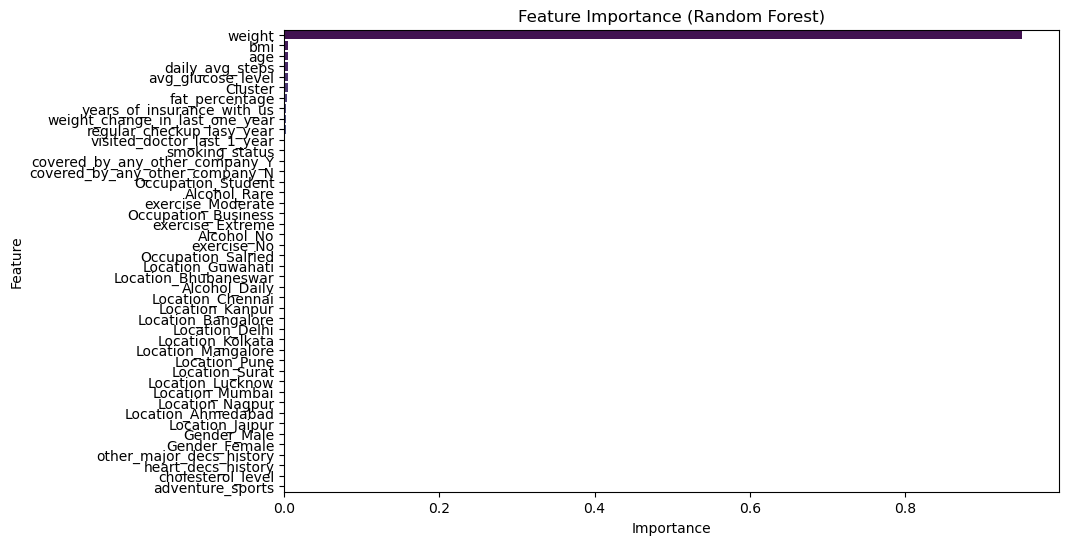

In [50]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

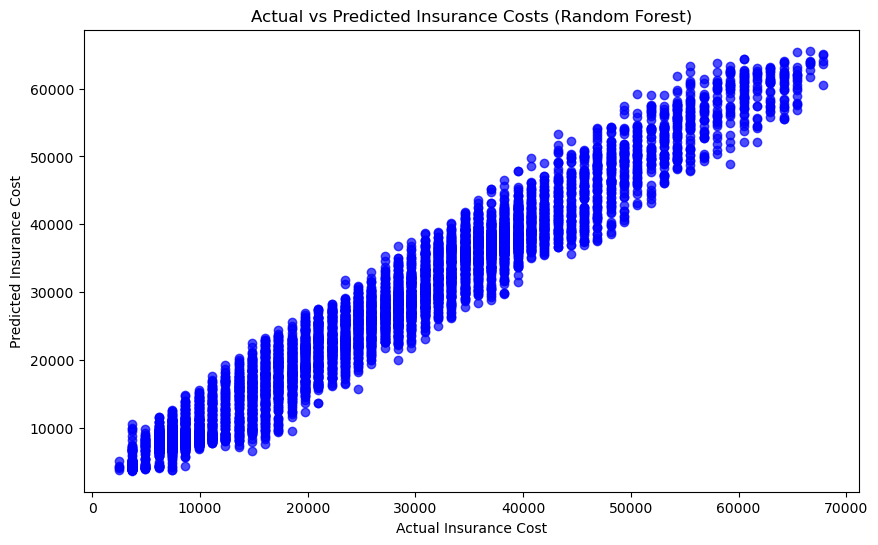

In [51]:
# Comparing true vs predicted values for the best model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='blue')
plt.xlabel('Actual Insurance Cost')
plt.ylabel('Predicted Insurance Cost')
plt.title('Actual vs Predicted Insurance Costs (Random Forest)')
plt.show()

# Model Tuning

In [52]:
# Decision Tree Tuning
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error']
}

grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                              dt_param_grid,
                              scoring='neg_mean_squared_error',
                              cv=3,
                              verbose=1,
                              n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\nTuned Decision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_best_dt))
print("MSE:", mean_squared_error(y_test, y_pred_best_dt))
print("R2 Score:", r2_score(y_test, y_pred_best_dt))

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Tuned Decision Tree:
MAE: 2527.896765969707
MSE: 10015439.596313411
R2 Score: 0.950437903707249


In [53]:
# Random Forest Tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                              rf_param_grid,
                              scoring='neg_mean_squared_error',
                              cv=3,
                              verbose=1,
                              n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\nTuned Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_best_rf))
print("MSE:", mean_squared_error(y_test, y_pred_best_rf))
print("R2 Score:", r2_score(y_test, y_pred_best_rf))

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Tuned Random Forest:
MAE: 2333.379623666326
MSE: 8574105.06049489
R2 Score: 0.9575704474530672



Model Comparison:
                  Model          MAE           MSE  R2 Score
0    Linear Regression  2709.210000  1.112779e+07  0.944900
1        Decision Tree  3199.350000  1.728815e+07  0.914400
2  Tuned Decision Tree  2527.896766  1.001544e+07  0.950438
3        Random Forest  2354.630000  8.765928e+06  0.956600
4  Tuned Random Forest  2333.379624  8.574105e+06  0.957570


C:\Users\nilan\AppData\Local\Temp\ipykernel_12248\2933133554.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis')


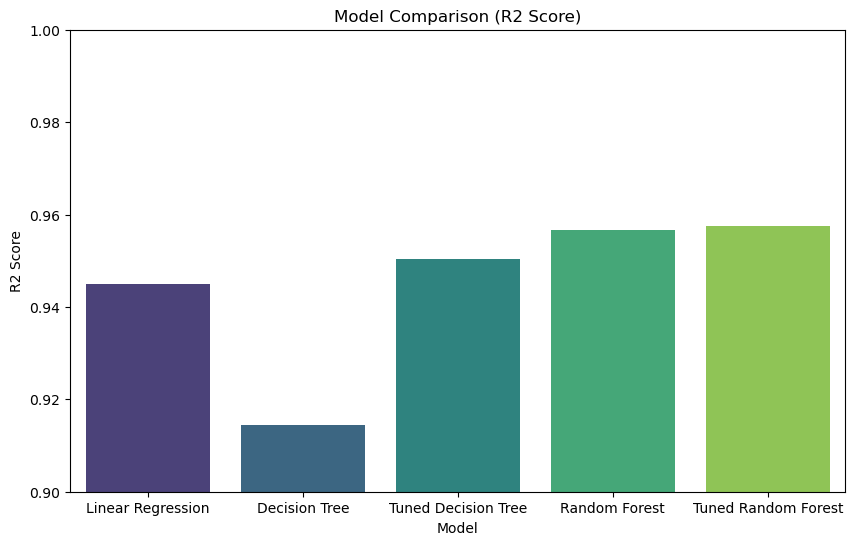

In [54]:
# Summary Comparison
models = ['Linear Regression', 'Decision Tree', 'Tuned Decision Tree', 'Random Forest', 'Tuned Random Forest']
mae_scores = [
    2709.21, 
    3199.35, 
    mean_absolute_error(y_test, y_pred_best_dt), 
    2354.63, 
    mean_absolute_error(y_test, y_pred_best_rf)
]
mse_scores = [
    11127794.30, 
    17288153.42, 
    mean_squared_error(y_test, y_pred_best_dt), 
    8765928.44, 
    mean_squared_error(y_test, y_pred_best_rf)
]
r2_scores = [
    0.9449, 
    0.9144, 
    r2_score(y_test, y_pred_best_dt), 
    0.9566, 
    r2_score(y_test, y_pred_best_rf)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'MAE': mae_scores,
    'MSE': mse_scores,
    'R2 Score': r2_scores
})
print("\nModel Comparison:\n", comparison_df)

# Visualization of Model Performance
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis')
plt.title('Model Comparison (R2 Score)')
plt.ylim(0.9, 1)
plt.show()

### Interpretation of the most optimum model

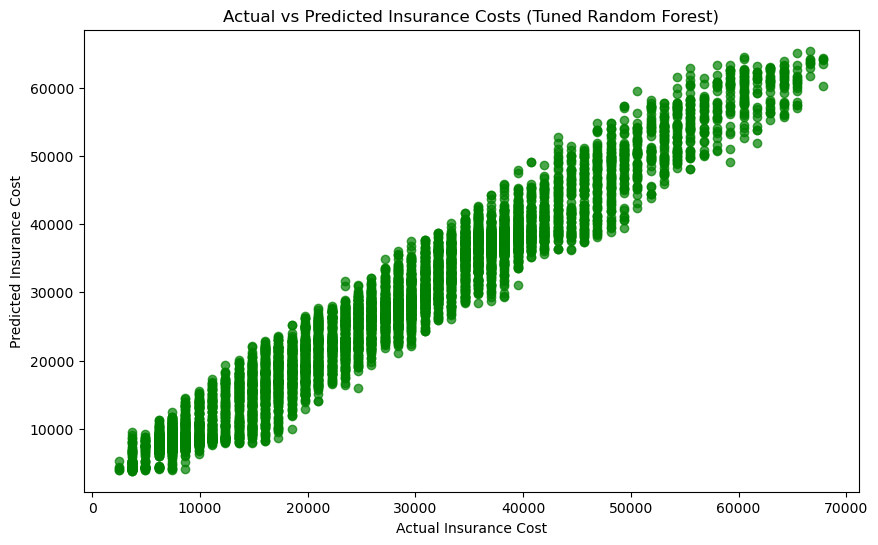

In [55]:
# Best Model Interpretation - Actual vs Predicted for Tuned Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best_rf, alpha=0.7, color='green')
plt.xlabel('Actual Insurance Cost')
plt.ylabel('Predicted Insurance Cost')
plt.title('Actual vs Predicted Insurance Costs (Tuned Random Forest)')
plt.show()